# Tallest Nations

Which countries produce the tallest people, and how big is the gap between men and women within each of them? This notebook pulls **Our World in Data**'s average-height-by-year-of-birth series for men and women and compares the 15 tallest countries.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

MEN_URL = "https://ourworldindata.org/grapher/average-height-of-men.csv"
WOMEN_URL = "https://ourworldindata.org/grapher/average-height-of-women.csv"
TOP_N = 15
HEADERS = {"User-Agent": "Mozilla/5.0"}


def load(url: str, value_col: str) -> pd.DataFrame:
    df = pd.read_csv(url, storage_options=HEADERS)
    df = df.rename(columns={df.columns[-1]: value_col})
    return df[df["Code"].notna() & ~df["Code"].str.startswith("OWID")]


men = load(MEN_URL, "male_cm")
women = load(WOMEN_URL, "female_cm")
merged = men.merge(women, on=["Entity", "Code", "Year"])
merged.tail()

,Entity,Code,Year,male_cm,female_cm
20195,Zimbabwe,ZWE,1992,169.34076,158.58394
20196,Zimbabwe,ZWE,1993,169.15228,158.49226
20197,Zimbabwe,ZWE,1994,168.96360,158.40002
20198,Zimbabwe,ZWE,1995,168.77493,158.30779
20199,Zimbabwe,ZWE,1996,168.58600,158.21518


## The 15 tallest countries

Using the most recent birth-year cohort with solid country coverage.

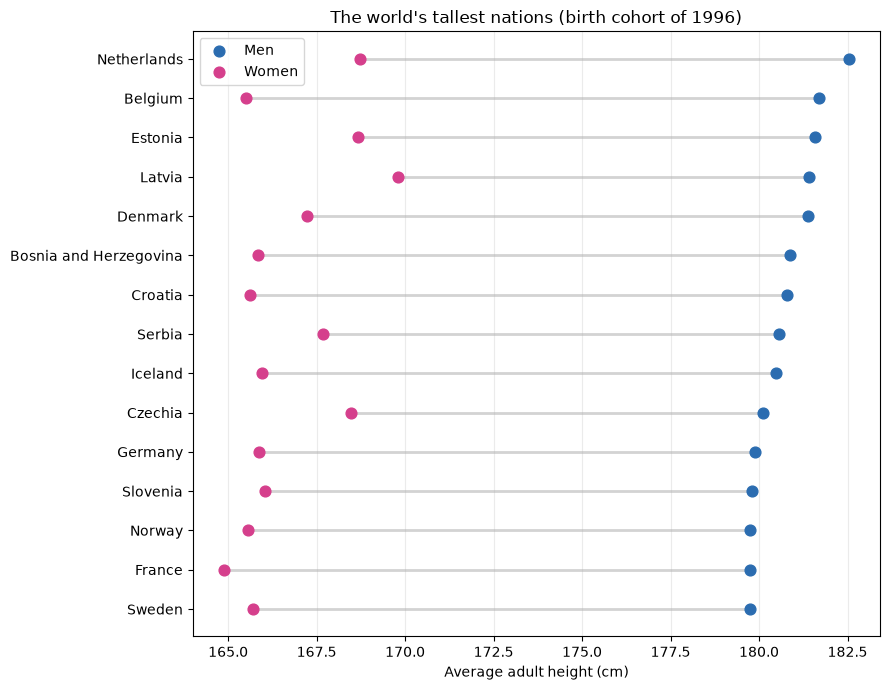

In [2]:
latest_year = merged.groupby("Year").size().loc[lambda s: s > 100].index.max()
latest = merged[merged["Year"] == latest_year]
top = latest.sort_values("male_cm", ascending=False).head(TOP_N).sort_values("male_cm")

fig, ax = plt.subplots(figsize=(9, 7))
ax.hlines(top["Entity"], top["female_cm"], top["male_cm"], color="lightgray", linewidth=2, zorder=1)
ax.scatter(top["male_cm"], top["Entity"], color="#2b6cb0", label="Men", zorder=2, s=60)
ax.scatter(top["female_cm"], top["Entity"], color="#d53f8c", label="Women", zorder=2, s=60)

ax.set_title(f"The world's tallest nations (birth cohort of {latest_year})")
ax.set_xlabel("Average adult height (cm)")
ax.legend()
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Biggest male-female height gap

In [3]:
gap = (top["male_cm"] - top["female_cm"]).sort_values(ascending=False)
for entity, value in gap.head(3).items():
    print(f"{top.loc[entity, 'Entity']}: {value:.1f} cm")

Belgium: 16.2 cm
Croatia: 15.2 cm
Bosnia and Herzegovina: 15.0 cm
